# Blood-Brain Barrier (BBB) Permeability Prediction
This project builds a machine learning pipeline to predict whether chemical compounds can cross the blood-brain barrier.
It compares different chemical feature representations (Morgan Fingerprints vs. MACCS keys) and ML models (SVM, Random Forest, Logistic Regression) to achieve the highest predictive accuracy.

Installing RDkit

In [25]:
!pip install rdkit

Import tools from rdkit, import pandas,numpy and other tools for data manipulation and cleaning, seaborn for visualization and sklearn for ml models

In [26]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_curve, RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


Sanity check

In [27]:
mol = Chem.MolFromSmiles('CC1=NN=C2N1C(=O)N(C=N2)C(=O)N')
print(f"Aspirin molecular weight: {Descriptors.MolWt(mol):2f}")

Aspirin molecular weight: 194.154000


### 1. Data Preparation
Here, we load the BBBP dataset and filter out invalid chemical structures (SMILES strings) to ensure high data quality for training.

Fetch dataset

In [28]:
import urllib.request

url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"

urllib.request.urlretrieve(url, "BBBP.csv")
print("Your dataset has downloaded successfully!")

Your dataset has downloaded successfully!


load data to pandas

In [29]:
df = pd.read_csv("BBBP.csv")
print(df.shape)
print(df.head())
print(df.columns.tolist())

(2050, 4)
   num                  name  p_np  \
0    1            Propanolol     1   
1    2  Terbutylchlorambucil     1   
2    3                 40730     1   
3    4                    24     1   
4    5           cloxacillin     1   

                                              smiles  
0                   [Cl].CC(C)NCC(O)COc1cccc2ccccc12  
1           C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl  
2  c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...  
3                   C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C  
4  Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...  
['num', 'name', 'p_np', 'smiles']


distribution of amount of permeable vs non-permeable molecules in the data set.

In [30]:
print("EDA class distribution")
print(df['p_np'].value_counts())
print(f"non-permeable (0):{(df['p_np']==0).sum()}molecules")
print(f"/npermeable (1): {df['p_np'].sum()}molecules")
pct=df['p_np'].mean()*100
print(f"Dataset is {pct:.1f}% permeable")

EDA class distribution
p_np
1    1567
0     483
Name: count, dtype: int64
non-permeable (0):483molecules
/npermeable (1): 1567molecules
Dataset is 76.4% permeable


Applying boolean mask to clean invalid smiles

In [31]:
df = df.dropna(subset=['smiles'])


df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)


valid_mask = df['mol'].notna()

invalid_df = df[~valid_mask]
df = df[valid_mask].reset_index(drop=True)

print(f"Invalid SMILES removed: {len(invalid_df)}")
print(f"Clean dataset size: {len(df)}")


[18:11:11] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] Explicit valence for atom # 6 N, 4, is greater than permitted
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] Explicit valence for atom # 6 N, 4, is greater than permitted
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] WARNING: not removing hydrogen atom without neighbors
[18:11:11] Explicit valence for atom # 11 N, 4, is greater than pe

Invalid SMILES removed: 11
Clean dataset size: 2039


[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors
[18:11:12] WARNING: not removing hydrogen atom without neighbors


visualization of molecules, first 6 permeable vs non permeable

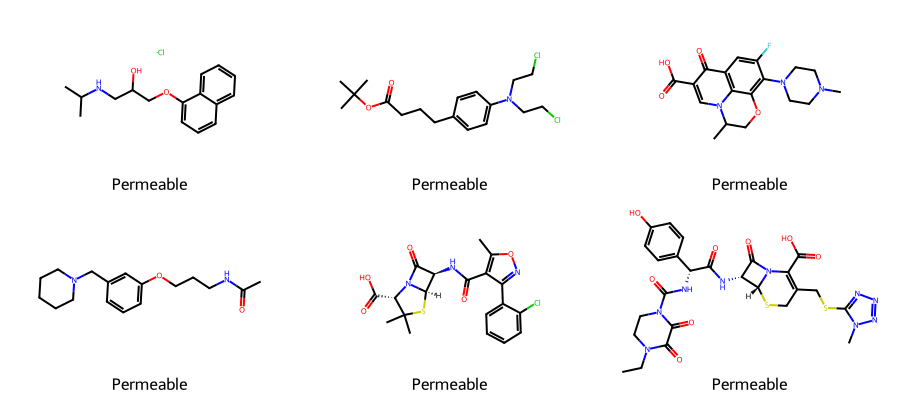

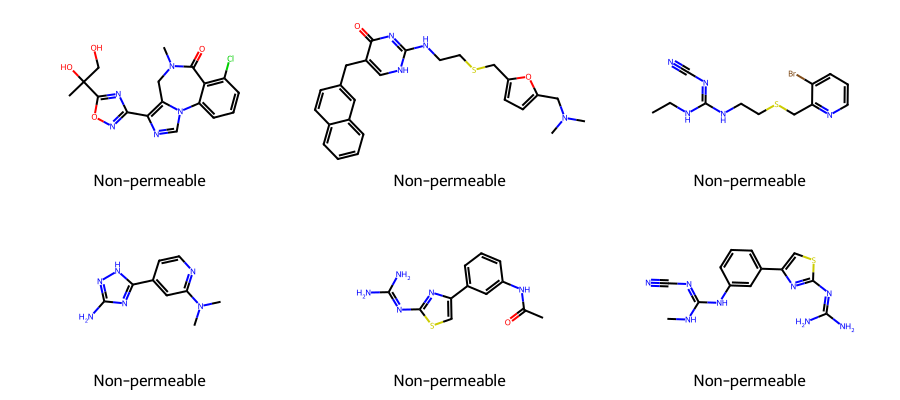

In [32]:
import os
from rdkit.Chem import Draw
from IPython.display import display
os.makedirs('figures', exist_ok=True)

#get molecules
permeable_mols=df[df['p_np']==1]['mol'].head(6).tolist()
non_permeable_mols=df[df['p_np']==0]['mol'].head(6).tolist()

#draw and save molecules
img1 = Draw.MolsToGridImage(permeable_mols, molsPerRow=3, subImgSize=(300, 200), legends=['Permeable'] * len(permeable_mols), returnPNG=False)
display(img1)
img1.save('figures/permeable_example.png')
img2 = Draw.MolsToGridImage(non_permeable_mols, molsPerRow=3, subImgSize=(300, 200), legends=['Non-permeable'] * len(non_permeable_mols), returnPNG=False)
display(img2)
img2.save('figures/non_permeable_example.png')



### 2. Feature Engineering
Machine learning models cannot "read" chemistry directly. We convert chemical structures into numerical vectors using:
- **Morgan Fingerprints**: Captures circular topological patterns.
- **MACCS Keys**: Encodes specific, human-interpretable structural fragments.

generate morgan fingerprints, MACCS keys and descriptors.

In [33]:
def get_morgan_fp(mol):
    fp = GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return np.array(fp)
morgan_fps = np.array([get_morgan_fp(mol) for mol in df['mol']])
print(f"Morgan fingerprint matrix shape: {morgan_fps.shape}")
def get_maccs_fp(mol):
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp)
maccs_fps = np.array([get_maccs_fp(mol) for mol in df['mol']])
print(f"MACCS keys matrix shape: {maccs_fps.shape}")
def get_descriptors(mol):
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol)
    }
desc_df = pd.DataFrame([get_descriptors(mol) for mol in df['mol']])
print(desc_df.describe())

[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerator
[18:11:12] DEPRECATION WARNING: please use MorganGenerat

Morgan fingerprint matrix shape: (2039, 2048)
MACCS keys matrix shape: (2039, 167)
             MolWt         LogP         TPSA          HBD          HBA  \
count  2039.000000  2039.000000  2039.000000  2039.000000  2039.000000   
mean    344.536290     2.318052    70.728499     1.546346     4.442864   
std     150.654103     2.092844    58.468574     1.840736     3.199691   
min      28.054000   -11.744600     0.000000     0.000000     0.000000   
25%     256.810000     1.253850    32.780000     0.000000     2.000000   
50%     324.406000     2.474700    55.120000     1.000000     4.000000   
75%     410.766500     3.745960    92.870000     2.000000     5.000000   
max    1879.680000    10.812700   662.410000    24.000000    33.000000   

          RotBonds  
count  2039.000000  
mean      4.198627  
std       3.043885  
min       0.000000  
25%       2.000000  
50%       4.000000  
75%       6.000000  
max      35.000000  


lipsinki's rule of 5 analysis for physical descriptors.

Lipinski pass rate by permeability:
p_np
0    0.647182
1    0.919231
Name: Lipinski_pass, dtype: float64


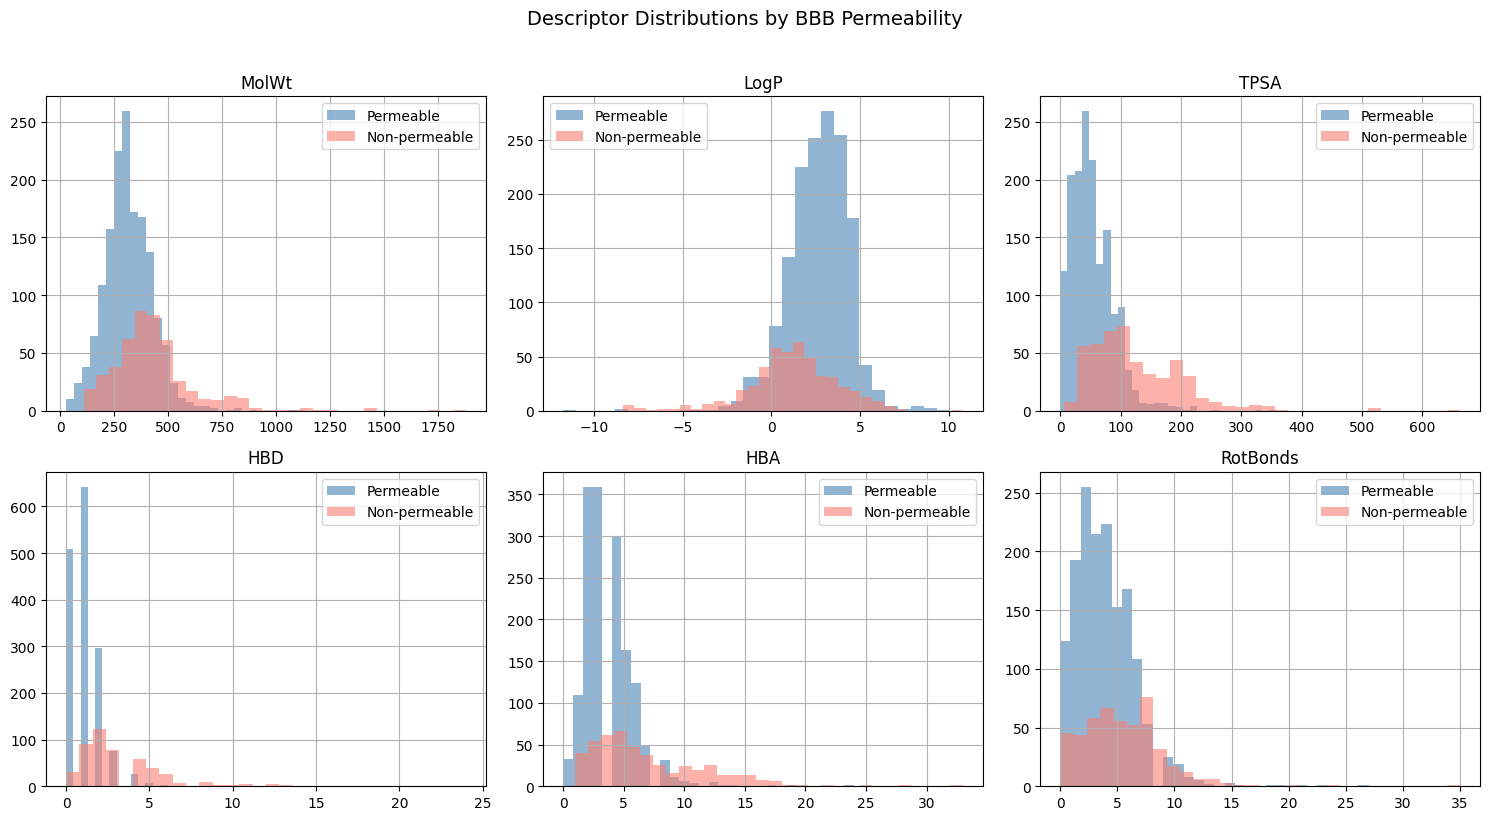

In [34]:
import matplotlib.pyplot as plt

def lipinski_pass(row):
    return (row['MolWt'] <= 500 and
            row['LogP'] <= 5 and
            row['HBD'] <= 5 and
            row['HBA'] <= 10)

desc_df['Lipinski_pass'] = desc_df.apply(lipinski_pass, axis=1)
desc_df['p_np'] = df['p_np'].values

print("Lipinski pass rate by permeability:")
print(desc_df.groupby('p_np')['Lipinski_pass'].mean())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
descriptors = ['MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds']

for ax, desc in zip(axes.flatten(), descriptors):
    desc_df[desc_df['p_np']==1][desc].hist(ax=ax, alpha=0.6, label='Permeable', color='steelblue', bins=30)
    desc_df[desc_df['p_np']==0][desc].hist(ax=ax, alpha=0.6, label='Non-permeable', color='salmon', bins=30)
    ax.set_title(desc)
    ax.legend()

plt.suptitle('Descriptor Distributions by BBB Permeability', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('figures/descriptor_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

91.9% of permeable mol pass the lipsinki's test, but 64.7% non permeable pass it too hence lipsinki test is not a good filter for BBB permeability, this promotes the use of an ML model to filter out non permeable molecules.

CNS MPO score is an Industry standard and can serve as a good benchmark.

Average CNS MPO score by permeability:
p_np
0    2.41
1    3.82
Name: CNS_MPO, dtype: float64


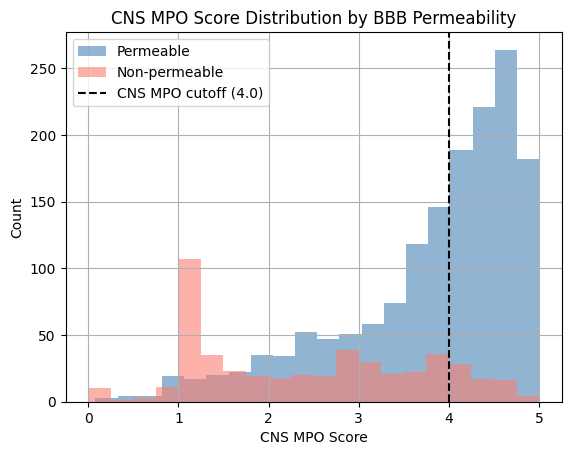

In [35]:
# CNS MPO SCORE from 0 to 6
def cns_mpo_score(row):
    score = 0
    score += 1 if row['LogP'] <= 3 else max(0, 1 - (row['LogP'] - 3) / 2)
    score += 1 if row['MolWt'] <= 360 else max(0, 1 - (row['MolWt'] - 360) / 100)
    score += 1 if row['TPSA'] <= 40 else max(0, 1 - (row['TPSA'] - 40) / 60)
    score += 1 if row['HBD'] == 0 else max(0, 1 - row['HBD'] / 3)
    score += 1 if row['HBA'] <= 4 else max(0, 1 - (row['HBA'] - 4) / 4)
    return round(score, 2)

desc_df['CNS_MPO'] = desc_df.apply(cns_mpo_score, axis=1)

print("Average CNS MPO score by permeability:")
print(desc_df.groupby('p_np')['CNS_MPO'].mean().round(2))

desc_df[desc_df['p_np']==1]['CNS_MPO'].hist(alpha=0.6, color='steelblue',
                                             label='Permeable', bins=20)
desc_df[desc_df['p_np']==0]['CNS_MPO'].hist(alpha=0.6, color='salmon',
                                             label='Non-permeable', bins=20)
plt.axvline(x=4, color='black', linestyle='--', label='CNS MPO cutoff (4.0)')
plt.xlabel('CNS MPO Score')
plt.ylabel('Count')
plt.title('CNS MPO Score Distribution by BBB Permeability')
plt.legend()
plt.savefig('figures/cns_mpo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

An avergae score of 3.82 for permeable and 2.41 for non permeable gives a good benchmark to compare to.

### 4. Machine Learning Pipeline
We perform a 3-way split (Train/Validation/Test) to prevent **data leakage**.
- **Train (60%)**: Used to teach the model.
- **Validation (20%)**: Used to compare different model architectures.
- **Test (20%)**: Held back entirely until the very end for unbiased evaluation.

In [36]:
from sklearn.model_selection import train_test_split

y = df['p_np'].values

# Step 1: Split off test set (20%)
X_morgan_temp, X_morgan_test, X_maccs_temp, X_maccs_test, y_temp, y_test = train_test_split(
    morgan_fps, maccs_fps, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 2: Split remaining 80% into train (75%) and validation (25%)
# 75% of 80% = 60% of total, 25% of 80% = 20% of total
X_morgan_train, X_morgan_val, X_maccs_train, X_maccs_val, y_train, y_val = train_test_split(
    X_morgan_temp, X_maccs_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print(f"Train:      {X_morgan_train.shape[0]} molecules (60%)")
print(f"Validation: {X_morgan_val.shape[0]} molecules (20%)")
print(f"Test:       {X_morgan_test.shape[0]} molecules (20%)")

Train:      1223 molecules (60%)
Validation: 408 molecules (20%)
Test:       408 molecules (20%)


### 5. Model Benchmarking
We compare multiple model architectures. We use `class_weight='balanced'` because our dataset has a significant imbalance between permeable and non-permeable classes.
Training all 6 model combinations (3 models × 2 fingerprints)
and comparing ROC-AUC scores.

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             precision_recall_curve, average_precision_score)

# Define models with balanced class weights to help with the 1567 vs 483 imbalance
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "SVM": SVC(
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
}


feature_sets = {
    "Morgan": (X_morgan_train, X_morgan_val, X_morgan_test),
    "MACCS": (X_maccs_train, X_maccs_val, X_maccs_test)
}

results = []


for fp_name, (X_tr, X_va, X_te) in feature_sets.items():
    for model_name, model in models.items():

        model.fit(X_tr, y_train)
        y_proba_val = model.predict_proba(X_va)[:, 1]
        y_pred_val = model.predict(X_va)
        cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='roc_auc')
        results.append({
            "Model": model_name,
            "Fingerprint": fp_name,
            "Val_AUC": round(roc_auc_score(y_val, y_proba_val), 3),
            "CV_AUC_mean": round(cv_scores.mean(), 3),
            "CV_AUC_std": round(cv_scores.std(), 3),
            "Accuracy": round(accuracy_score(y_val, y_pred_val), 3),
            "NP_Recall": round(recall_score(y_val, y_pred_val, pos_label=0), 3),
            "NP_Precision": round(precision_score(y_val, y_pred_val, pos_label=0, zero_division=0), 3),
            "P_Recall": round(recall_score(y_val, y_pred_val, pos_label=1), 3),
            "P_Precision": round(precision_score(y_val, y_pred_val, pos_label=1), 3)
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val_AUC', ascending=False)

print("RESULTS (sorted by Validation ROC-AUC)")
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison.csv', index=False)

RESULTS (sorted by Validation ROC-AUC)
              Model Fingerprint  Val_AUC  CV_AUC_mean  CV_AUC_std  Accuracy  NP_Recall  NP_Precision  P_Recall  P_Precision
                SVM      Morgan    0.897        0.914       0.017     0.863      0.677         0.722     0.920        0.903
      Random Forest      Morgan    0.895        0.899       0.014     0.868      0.542         0.839     0.968        0.873
      Random Forest       MACCS    0.893        0.914       0.021     0.870      0.583         0.812     0.958        0.882
Logistic Regression      Morgan    0.884        0.911       0.013     0.846      0.677         0.670     0.897        0.900
                SVM       MACCS    0.883        0.909       0.025     0.838      0.750         0.632     0.865        0.918
Logistic Regression       MACCS    0.872        0.872       0.016     0.838      0.740         0.634     0.869        0.916


looking at the table RF+MACCS shows best possible results

Model performance chart based on ROC-AUC scores.

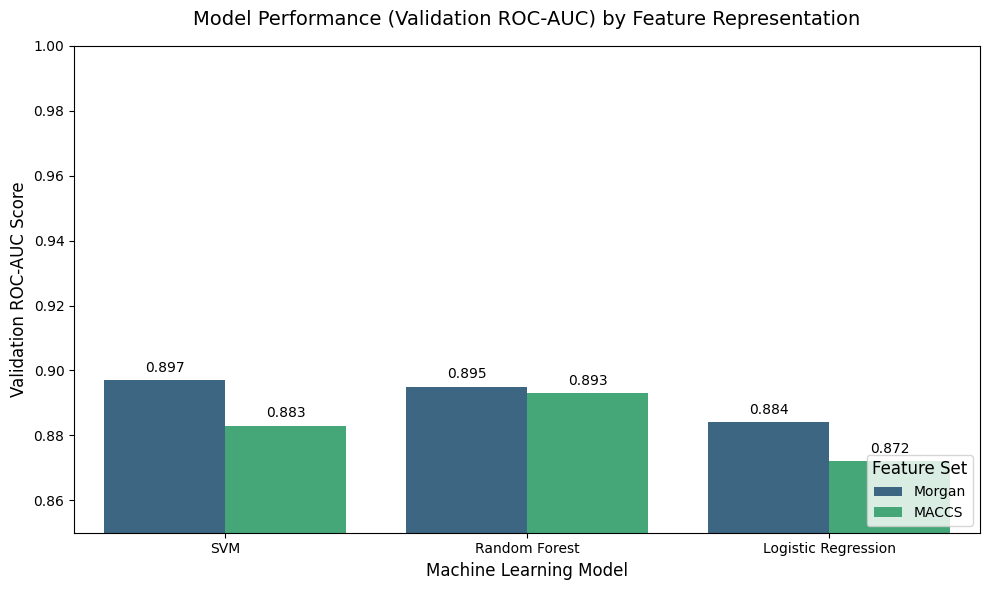

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='Val_AUC', hue='Fingerprint', palette='viridis')
plt.title('Model Performance (Validation ROC-AUC) by Feature Representation', fontsize=14, pad=15)
plt.ylabel('Validation ROC-AUC Score', fontsize=12)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylim(0.85, 1.0)
plt.legend(title='Feature Set', title_fontsize='12', fontsize='10', loc='lower right')
for p in plt.gca().patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        plt.gca().annotate(f"{height:.3f}",
                           (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='center',
                           xytext=(0, 9),
                           textcoords='offset points')

plt.tight_layout()
plt.savefig('figures/model_comparison_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Threshold Optimization
By default, models use a 0.5 threshold. We perform a threshold sweep on the validation set to find the optimal operating point that balances precision and recall for our specific needs.

In [56]:
from sklearn.svm import SVC
from sklearn.metrics import recall_score, precision_score, accuracy_score

best_model = SVC(
    probability=True,
    class_weight='balanced',
    random_state=42
)
best_model.fit(X_morgan_train, y_train)

# Get probabilities on the VALIDATION SET
y_val_proba = best_model.predict_proba(X_morgan_val)[:, 1]

# Threshold sweep on validation set
print("THRESHOLD SWEEP (on Validation Set)")
print("-" * 70)
print("Threshold | Accuracy | NP Recall | NP Precision | P Recall | P Precision")
print("-" * 70)

for thresh in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.67, 0.7]:
    y_val_pred = (y_val_proba >= thresh).astype(int)
    acc      = accuracy_score(y_val, y_val_pred)
    rec_np   = recall_score(y_val, y_val_pred, pos_label=0, zero_division=0)
    prec_np  = precision_score(y_val, y_val_pred, pos_label=0, zero_division=0)
    rec_p    = recall_score(y_val, y_val_pred, pos_label=1)
    prec_p   = precision_score(y_val, y_val_pred, pos_label=1)
    marker   = " <-- default" if thresh == 0.5 else ""
    print(f"   {thresh:.2f}   |  {acc:.3f}   |   {rec_np:.3f}   |"
          f"     {prec_np:.3f}     |  {rec_p:.3f}  |  {prec_p:.3f}{marker}")

MY_THRESHOLD = 0.67
print(f"\nChosen threshold: {MY_THRESHOLD} (selected on validation set)")

THRESHOLD SWEEP (on Validation Set)
----------------------------------------------------------------------
Threshold | Accuracy | NP Recall | NP Precision | P Recall | P Precision
----------------------------------------------------------------------
   0.30   |  0.863   |   0.510   |     0.845     |  0.971  |  0.866
   0.35   |  0.868   |   0.562   |     0.818     |  0.962  |  0.877
   0.40   |  0.868   |   0.604   |     0.784     |  0.949  |  0.886
   0.45   |  0.860   |   0.615   |     0.747     |  0.936  |  0.888
   0.50   |  0.860   |   0.635   |     0.735     |  0.929  |  0.892 <-- default
   0.55   |  0.863   |   0.656   |     0.733     |  0.926  |  0.898
   0.60   |  0.863   |   0.688   |     0.717     |  0.917  |  0.905
   0.65   |  0.860   |   0.708   |     0.701     |  0.907  |  0.910
   0.67   |  0.860   |   0.719   |     0.697     |  0.904  |  0.913
   0.70   |  0.863   |   0.760   |     0.689     |  0.894  |  0.924

Chosen threshold: 0.67 (selected on validation set)


Confusion matrix + ROC + Precision-Recall

FINAL MODEL EVALUATION (Threshold = 0.67)
               precision    recall  f1-score   support

Non-permeable       0.77      0.77      0.77        96
    Permeable       0.93      0.93      0.93       312

     accuracy                           0.89       408
    macro avg       0.85      0.85      0.85       408
 weighted avg       0.89      0.89      0.89       408

ROC-AUC: 0.923


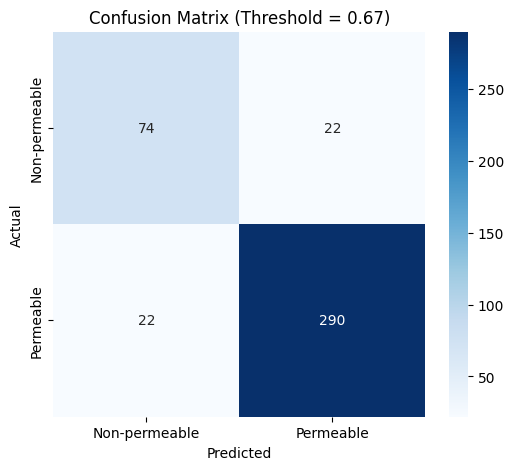

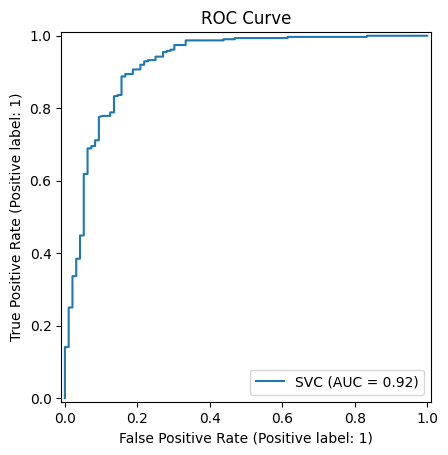

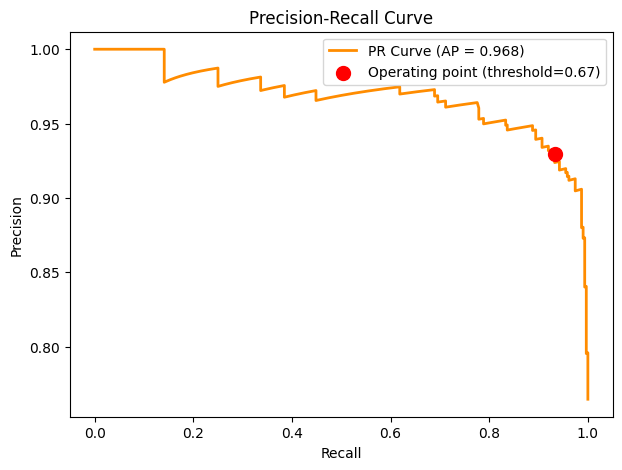

In [40]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve,
                             average_precision_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# Get test set probabilities
y_test_proba = best_model.predict_proba(X_morgan_test)[:, 1]

# Apply chosen threshold
y_pred_final = (y_test_proba >= MY_THRESHOLD).astype(int)

print(f"FINAL MODEL EVALUATION (Threshold = {MY_THRESHOLD})")
print(classification_report(y_test, y_pred_final,
      target_names=['Non-permeable', 'Permeable']))

roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-permeable', 'Permeable'],
            yticklabels=['Non-permeable', 'Permeable'])
plt.title(f'Confusion Matrix (Threshold = {MY_THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(best_model, X_morgan_test, y_test)
plt.title('ROC Curve')
plt.savefig('figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision-Recall Curve with operating point marked
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_test_proba)
avg_precision = average_precision_score(y_test, y_test_proba)


op_idx = np.argmin(np.abs(thresholds - MY_THRESHOLD))
op_recall    = recall_vals[op_idx]
op_precision = precision_vals[op_idx]

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, color='darkorange', lw=2,
         label=f'PR Curve (AP = {avg_precision:.3f})')
plt.scatter(op_recall, op_precision, color='red', s=100, zorder=5,
            label=f'Operating point (threshold={MY_THRESHOLD})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig('figures/precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

#7. Error Analysis
No model is perfect. Here, we inspect our "False Positives" and "False Negatives" to understand the chemical motifs that consistently trick the model.

y_test length: 408
test_df length: 408
FALSE POSITIVES: 22 (predicted permeable, actually NOT)


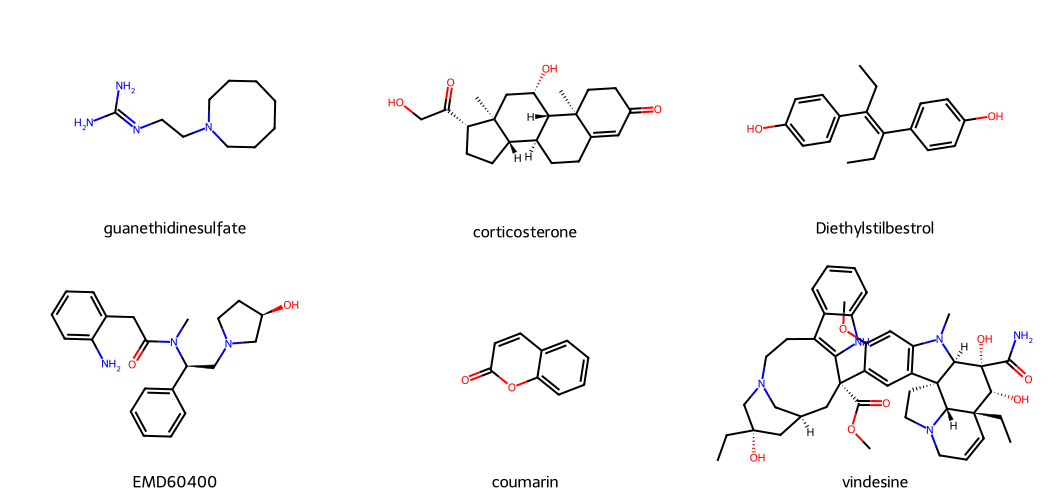

FALSE NEGATIVES: 22 (predicted non-permeable, actually IS)


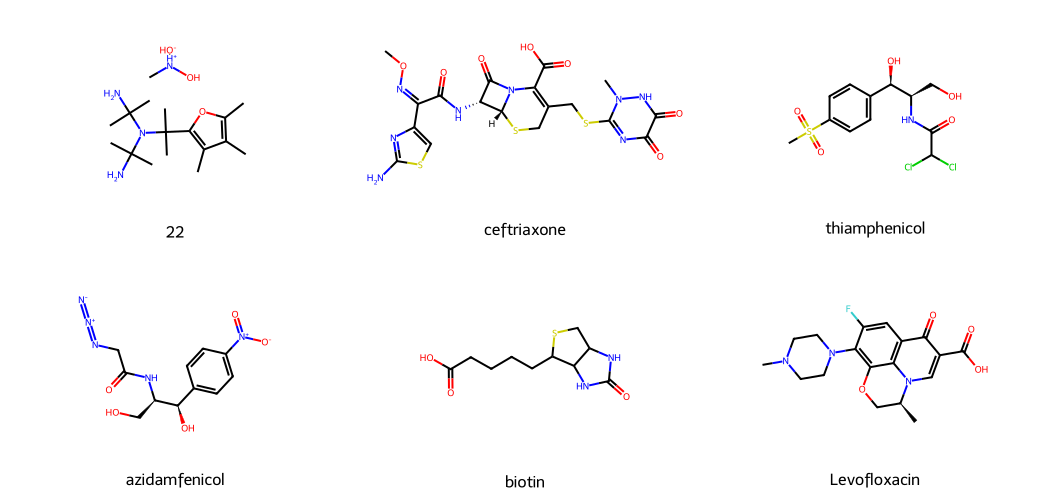

In [41]:
from rdkit.Chem import Draw
from IPython.display import display
import pandas as pd
import numpy as np

def save_grid(img, path):
    png = img._repr_png_()
    if isinstance(png, str):
        import base64
        png = base64.b64decode(png)
    with open(path, 'wb') as f:
        f.write(png)

# Re-create the index split to match your Test set (408 molecules)
all_indices = np.arange(len(df))
_, test_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    stratify=df['p_np'].values
)

# Extract only the test rows from the original df
test_df = df.iloc[test_indices].reset_index(drop=True)

# Verify alignment: Both should be 408
print(f"y_test length: {len(y_test)}")
print(f"test_df length: {len(test_df)}")

# Calculate errors
wrong_idx = np.where(y_pred_final != y_test)[0]
false_pos = wrong_idx[y_test[wrong_idx] == 0]
false_neg = wrong_idx[y_test[wrong_idx] == 1]

# Visualization
if len(false_pos) > 0:
    print(f"FALSE POSITIVES: {len(false_pos)} (predicted permeable, actually NOT)")
    fp_mols   = [test_df.iloc[i]['mol'] for i in false_pos[:6]]
    fp_labels = [test_df.iloc[i]['name'] for i in false_pos[:6]]
    img1 = Draw.MolsToGridImage(fp_mols, molsPerRow=3,
                                subImgSize=(350, 250), legends=fp_labels)
    display(img1)
    save_grid(img1, 'figures/false_positives.png')

if len(false_neg) > 0:
    print(f"FALSE NEGATIVES: {len(false_neg)} (predicted non-permeable, actually IS)")
    fn_mols   = [test_df.iloc[i]['mol'] for i in false_neg[:6]]
    fn_labels = [test_df.iloc[i]['name'] for i in false_neg[:6]]
    img2 = Draw.MolsToGridImage(fn_mols, molsPerRow=3,
                                subImgSize=(350, 250), legends=fn_labels)
    display(img2)
    save_grid(img2, 'figures/false_negatives.png')

#8. Feature Importance
To ensure the model is "interpretable," we calculate the importance of specific fingerprint bits. This reveals the chemical features (like specific ring structures or functional groups) the SVM relies on most heavily to make its predictions.

In [42]:
# TRAINING CELL
from sklearn.svm import SVC

# Define and train the champion model
best_model = SVC(
    kernel='linear',
    probability=True,
    class_weight='balanced',
    random_state=42
)

best_model.fit(X_morgan_train, y_train)
print("Champion Model (Linear SVM) trained successfully on Morgan features!")

Champion Model (Linear SVM) trained successfully on Morgan features!


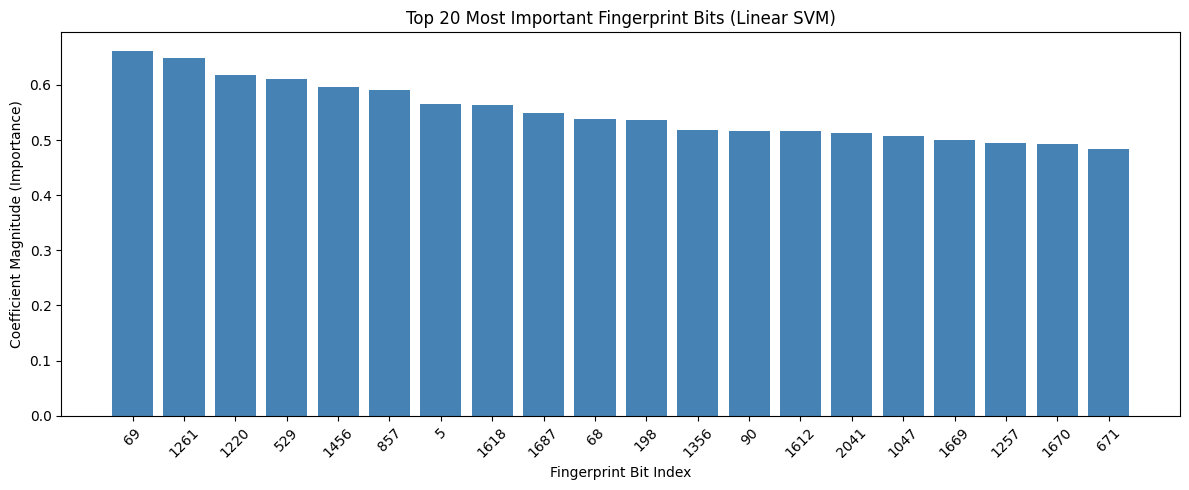

In [43]:
# FEATURE IMPORTANCE CELL
import numpy as np
import matplotlib.pyplot as plt

importances = np.abs(best_model.coef_[0])
top_20_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), importances[top_20_idx], color='steelblue')
plt.xticks(range(20), top_20_idx, rotation=45)
plt.xlabel('Fingerprint Bit Index')
plt.ylabel('Coefficient Magnitude (Importance)')
plt.title('Top 20 Most Important Fingerprint Bits (Linear SVM)')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# **Final result**
Real drug prediction using Caffiene and penicillin

In [48]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

real_world_drugs = {
    "caffiene":         "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Penicillin V": "CC1(C(N2C(S1)C(C2=O)NC(=O)COc3ccccc3)C(=O)O)C",

}


for name, smiles in real_world_drugs.items():
    mol = Chem.MolFromSmiles(smiles)

    fp_vec = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

    # 2. Convert to numpy array and reshape
    fp = np.zeros((1,))
    Chem.DataStructs.ConvertToNumpyArray(fp_vec, fp)
    fp = fp.reshape(1, -1)
    proba = best_model.predict_proba(fp)[0][1]
    prediction = 1 if proba >= MY_THRESHOLD else 0
    result     = "CROSSES BBB" if prediction == 1 else "Does NOT cross BBB"
    confidence = proba * 100 if prediction == 1 else (1 - proba) * 100

    print(f"Drug: {name}")
    print(f"Prediction: {result} (Confidence: {confidence:.1f}%)\n")

Drug: caffiene
Prediction: CROSSES BBB (Confidence: 98.4%)

Drug: Penicillin V
Prediction: Does NOT cross BBB (Confidence: 86.8%)



[18:28:38] DEPRECATION WARNING: please use MorganGenerator
[18:28:38] DEPRECATION WARNING: please use MorganGenerator


In [55]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

real_world_drugs = {
    "caffiene":         "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Penicillin V": "CC1(C(N2C(S1)C(C2=O)NC(=O)COc3ccccc3)C(=O)O)C",
    "Nicotine": "CN1CCC[C@H]1c2cccnc2",
    "Diazepam": "CN1C(=O)CN=C(c2ccccc2)c3cc(Cl)ccc13",
    "Ethanol": "CCO",
    "Fentanyl":"CCN(C(=O)CCC)C1(CCN(CC1)CCc2ccccc2)c3ccccc3",
    "Glucose": "O[C@H]1[C@H](O)[C@@H](O)[C@H](O)[C@H](CO)O1",
    "Histamine": "NCCc1c[nH]cn1",
    "Sucrose": "OC[C@H]1O[C@H](OC[C@H]2O[C@H](O)[C@H](O)[C@@H]2O)[C@H](O)[C@@H]1O",
    "Dopamine": "NCCc1ccc(O)c(O)c1",
    "Methotrexate": "CN(Cc2cnc1c(nc(N)nc1N)n2)c3ccc(C(=O)NC(CCC(=O)O)C(=O)O)cc3"

}


for name, smiles in real_world_drugs.items():
    mol = Chem.MolFromSmiles(smiles)

    fp_vec = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

    # 2. Convert to numpy array and reshape
    fp = np.zeros((1,))
    Chem.DataStructs.ConvertToNumpyArray(fp_vec, fp)
    fp = fp.reshape(1, -1)
    proba = best_model.predict_proba(fp)[0][1]
    prediction = 1 if proba >= MY_THRESHOLD else 0
    result     = "CROSSES BBB" if prediction == 1 else "Does NOT cross BBB"
    confidence = proba * 100 if prediction == 1 else (1 - proba) * 100

    print(f"Drug: {name}")
    print(f"Prediction: {result} (Confidence: {confidence:.1f}%)\n")

Drug: caffiene
Prediction: CROSSES BBB (Confidence: 98.4%)

Drug: Penicillin V
Prediction: Does NOT cross BBB (Confidence: 86.8%)

Drug: Nicotine
Prediction: CROSSES BBB (Confidence: 96.3%)

Drug: Diazepam
Prediction: CROSSES BBB (Confidence: 98.3%)

Drug: Ethanol
Prediction: CROSSES BBB (Confidence: 86.4%)

Drug: Fentanyl
Prediction: CROSSES BBB (Confidence: 99.0%)

Drug: Glucose
Prediction: CROSSES BBB (Confidence: 83.2%)

Drug: Histamine
Prediction: CROSSES BBB (Confidence: 80.6%)

Drug: Sucrose
Prediction: CROSSES BBB (Confidence: 72.3%)

Drug: Dopamine
Prediction: Does NOT cross BBB (Confidence: 73.7%)

Drug: Methotrexate
Prediction: Does NOT cross BBB (Confidence: 65.0%)



[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator
[18:36:12] DEPRECATION WARNING: please use MorganGenerator


# **Conclusion**
The final SVM model successfully predicts passive Blood-Brain Barrier (BBB) permeability for a wide range of chemical compounds. It performs particularly well on permeable molecules, reflecting the underlying class distribution of the training data. However, real-world drug testing revealed important biological limitations, specifically regarding false positives like Sucrose, Glucose, and Histamine. These misclassifications occur because the model was trained exclusively on 2D structural representations (Morgan fingerprints and MACCS keys). Because it lacks the context of 1D physical descriptors (like Molecular Weight and Polarity) it struggles to penalize massive or highly polar molecules. Furthermore, it predicts based strictly on passive diffusion and cannot account for active biological transport mechanisms, such as the GLUT1 transporters required for Glucose.